# Gaussianization Flow on Two-Moons

A minimal demonstration of a *Gaussianization flow* — a normalising flow built from two kinds of bijectors stacked in blocks:

1. **Rotation.** Either a Householder product (trainable, $Q = \prod_j (I - 2 v_j v_j^\top / \lVert v_j \rVert^2)$) or a fixed orthogonal matrix (frozen at initialisation, optionally from the data PCA). Rotations have $\log\lvert\det J\rvert = 0$, so they are "free" — their only job is to redistribute non-Gaussianity across dimensions.
2. **Marginal Gaussianization.** For each dimension independently, apply $z_i = \Phi^{-1}(F_i(x_i))$ where $F_i$ is a trainable mixture-of-Gaussians CDF. This is where the flow does its work: after enough stacked blocks, the pushforward is approximately $\mathcal{N}(0, I)$.

The model is trained end-to-end by maximising
$$\log p_X(x) \;=\; \log p_Z(f(x)) \;+\; \sum_\ell \log\lvert\det J_{f_\ell}(\cdot)\rvert$$
with $p_Z = \mathcal{N}(0, I)$. In flowjax this is just `-flow.log_prob(x).mean()`; `fit_to_data` handles the rest.

## Mathematical background

### The 1-D probability integral transform

For a univariate random variable $X \sim p$ with strictly increasing CDF $F$, the classical result is that $F(X) \sim \text{Uniform}[0, 1]$. Composing with the standard-normal quantile $\Phi^{-1}$ gives
$$z \;=\; \Phi^{-1}\!\big(F(x)\big) \;\sim\; \mathcal{N}(0, 1).$$
So *in 1-D* we can Gaussianize any continuous distribution exactly, given its true CDF. The catch is that we don't know $F$; we have to estimate it.

### Mixture-of-Gaussians CDF

We approximate $F$ with a mixture of $K$ normals,
$$F(x;\,\pi, \mu, \sigma) \;=\; \sum_{k=1}^{K} \pi_k \,\Phi\!\big((x - \mu_k)/\sigma_k\big),$$
with $\pi \in \Delta^{K-1}$, $\mu \in \mathbb{R}^K$, $\sigma \in \mathbb{R}_{>0}^K$. The corresponding pdf is
$$f(x;\,\pi, \mu, \sigma) \;=\; \sum_{k} \pi_k \,\sigma_k^{-1}\,\varphi\!\big((x - \mu_k)/\sigma_k\big).$$
For $d$ input dimensions we fit one such mixture *per dim independently* — parameter tensors all have shape $(d, K)$ in our layer, so for $d = 2$ and $K = 8$ that's $3 \cdot 2 \cdot 8 = 48$ numbers. The forward map and its log-derivative on dim $i$ are
$$z_i \;=\; \Phi^{-1}\!\big(F_i(x_i)\big), \qquad \log\lvert \partial z_i / \partial x_i \rvert \;=\; \log f_i(x_i) \;-\; \log \varphi(z_i).$$

### Log-determinant structure of a flow block

One block is `rotation → marginal`. With $x \in \mathbb{R}^d$ for any $d$, the rotation $Q \in O(d)$ has $\log\lvert\det Q\rvert = 0$, so it contributes nothing. The marginal's Jacobian is diagonal, so
$$\log\lvert\det J_{\text{block}}(x) \rvert \;=\; \sum_{i = 1}^{d} \big[\log f_i(x_i^{\text{rot}}) - \log \varphi(z_i)\big]$$
with $x^{\text{rot}} = Q x$ and $z_i = \Phi^{-1}(F_i(x_i^{\text{rot}}))$. Stacking $L$ blocks sums $L$ such terms. Everything is differentiable, so we can train by maximum likelihood.

### Iterative vs parametric Gaussianization

Two ways to choose the block parameters $\{(Q_\ell, \pi_\ell, \mu_\ell, \sigma_\ell)\}_{\ell=1}^L$ — same architecture, very different philosophies.

- **Iterative Gaussianization (RBIG — Laparra & Malo 2011)**: greedy, non-gradient, one block at a time. Given the current state $Y$, fit $Q_\ell = $ PCA$(Y)$, rotate, fit a per-dim GMM on the rotated data, apply the marginal transform numerically, move on. Laparra shows the negentropy $J(Y_\ell) = D_\text{KL}(Y_\ell \,\|\, \mathcal{N}(0, I))$ decreases at a **geometric** rate under mild conditions. No gradients ever flow — each block is fit once and frozen. Cheap, remarkably good, and a useful *warm start* (see notebook 03).
- **Parametric Gaussianization**: the flow is the same architecture, but *all* parameters $(\pi, \mu, \sigma, Q)$ across all blocks are learned jointly by gradient descent on the exact NLL. Gradients backprop through the composition, so later blocks can *compensate* for finite-$K$ approximation errors in earlier blocks — something RBIG fundamentally cannot do. This notebook trains a parametric Gaussianization flow from scratch.

Both target the same optimum ($p_Z = \mathcal{N}$ on the latent), but the *path* to it is different. Empirically, parametric + IG warm-start is the best of both worlds — notebook 03 shows the numbers.

In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from flowjax.train import fit_to_data
from sklearn.datasets import make_moons

from gauss_flows import gaussianization_flow


# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset: two moons

Standardised so each dimension has unit variance, which keeps the initial mixture-component scales (initialised to $\sigma = 1$) well-matched to the data.

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


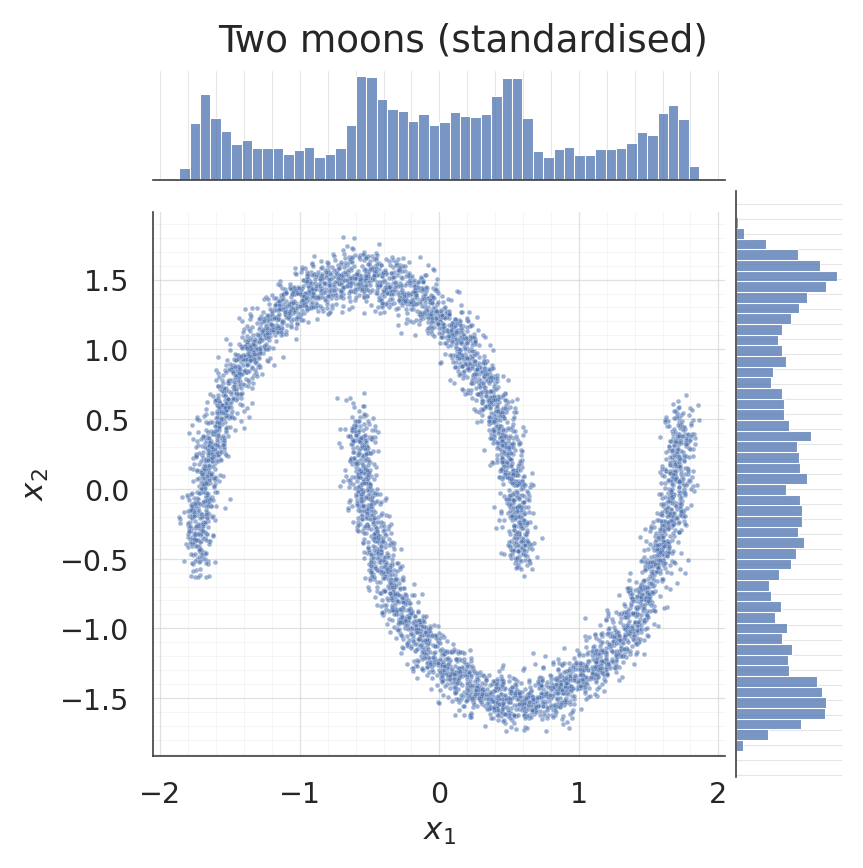

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = jnp.asarray(X, dtype=jnp.float32)

g = sns.jointplot(
    x=np.asarray(X[:, 0]),
    y=np.asarray(X[:, 1]),
    kind="scatter",
    color=palette[0],
    height=7.5,
    ratio=5,
    space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={"bins": 50, "color": palette[0], "alpha": 0.75, "edgecolor": "white"},
)
g.set_axis_labels("$x_1$", "$x_2$")
g.figure.suptitle("Two moons (standardised)", y=1.02)
style_jointgrid(g)
plt.show()

## 2. Build the flow

Eight blocks of `[MixtureGaussianCDF, HouseholderRotation]` (the flowjax equivalent of the Keras `(Householder, MixtureCDFGaussianization)` pair). Mixture means are initialised from `Uniform(-3, 3)` and Householder reflector vectors from a standard normal; this breaks the init symmetry so training sees useful gradients from epoch 0.

In [3]:
key = jr.key(0)
flow_key, train_key, sample_key = jr.split(key, 3)

flow = gaussianization_flow(
    flow_key,
    n_dims=2,
    n_layers=8,
    n_components=8,
    n_reflections=2,
    rotation="householder",
)

n_params = sum(
    int(np.prod(p.shape))
    for p in jax.tree_util.tree_leaves(eqx.filter(flow, eqx.is_array))
)
print(f"number of blocks           : 8")
print(f"mixture components / dim   : 8")
print(f"total trainable parameters : {n_params}")

number of blocks           : 8
mixture components / dim   : 8
total trainable parameters : 420


## 3. Train

End-to-end gradient descent with Adam via `flowjax.train.fit_to_data`. The loss is the exact per-sample NLL; the Jacobian log-dets are threaded through automatically by flowjax.

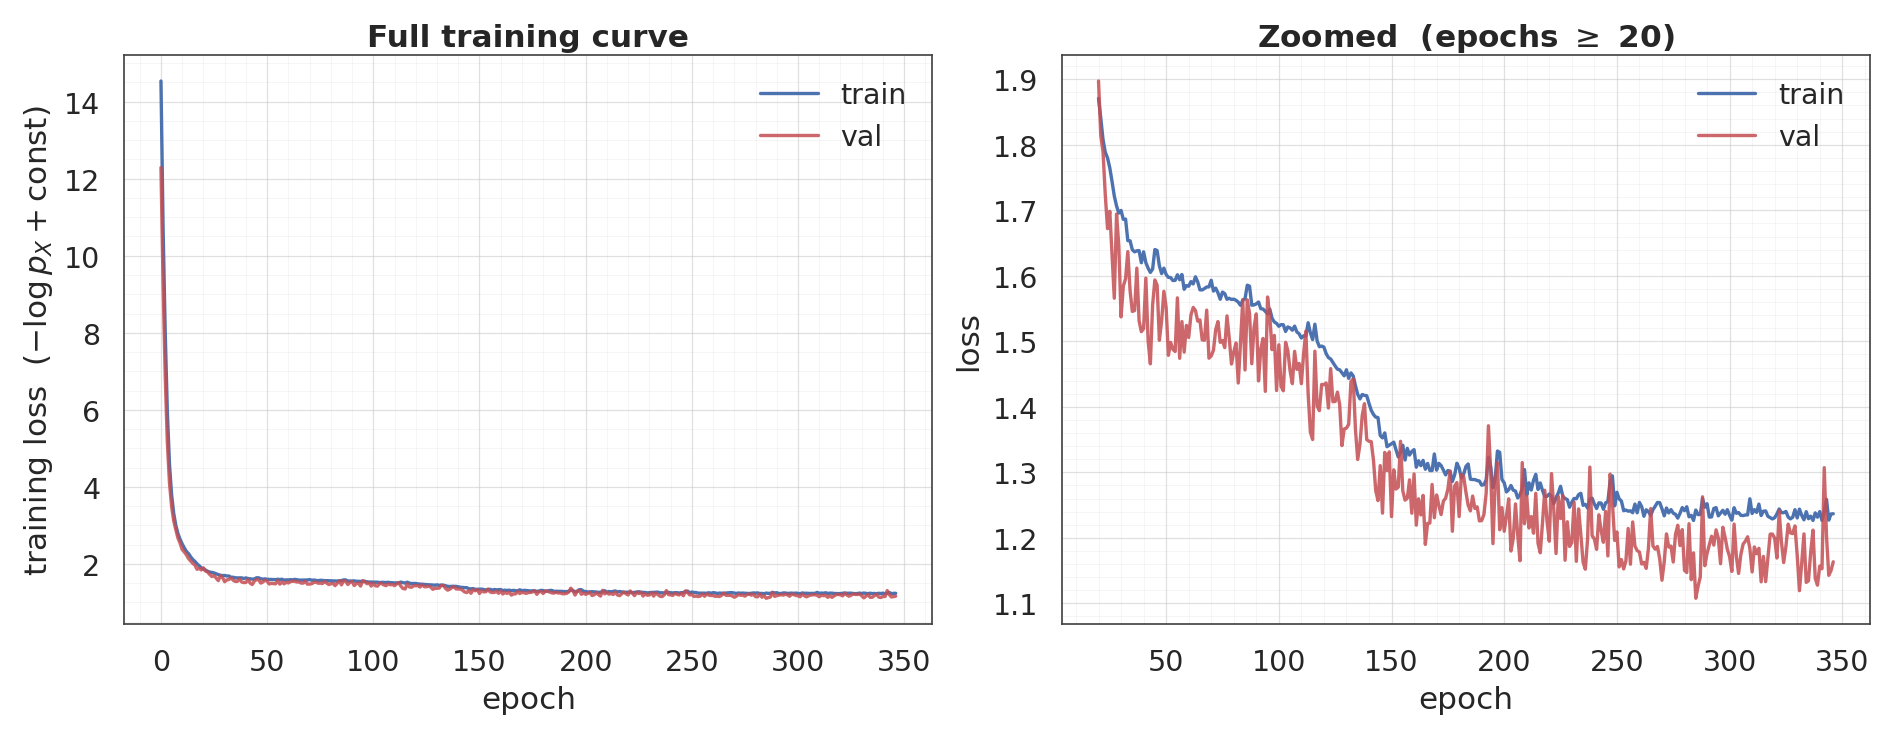

final train NLL: +1.2368   (min: +1.2266)
final   val NLL: +1.1635   (min: +1.1078)


In [4]:
trained, losses = fit_to_data(
    train_key,
    flow,
    X,
    learning_rate=5e-3,
    max_epochs=600,
    max_patience=60,
    batch_size=256,
    val_prop=0.1,
    show_progress=False,
)
train_loss = np.asarray(losses["train"])
val_loss = np.asarray(losses["val"])

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
c = palette[0]
ax = axes[0]
ax.plot(train_loss, color=c, linewidth=2.2, label="train")
ax.plot(val_loss, color=palette[3], linewidth=2.2, alpha=0.85, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel(r"training loss  $(-\log p_X + \text{const})$")
ax.set_title("Full training curve")
ax.legend(frameon=False)
style_axes(ax)

ax = axes[1]
tail_start = 20
tail = train_loss[tail_start:]
tail_v = val_loss[tail_start:]
ax.plot(range(tail_start, len(train_loss)), tail, color=c, linewidth=2.2, label="train")
ax.plot(
    range(tail_start, len(val_loss)),
    tail_v,
    color=palette[3],
    linewidth=2.2,
    alpha=0.85,
    label="val",
)
span = max(tail.max(), tail_v.max()) - min(tail.min(), tail_v.min())
ax.set_ylim(
    min(tail.min(), tail_v.min()) - 0.05 * span,
    max(tail.max(), tail_v.max()) + 0.05 * span,
)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title(f"Zoomed  (epochs $\\geq$ {tail_start})")
ax.legend(frameon=False)
style_axes(ax)

plt.show()
print(f"final train NLL: {train_loss[-1]:+.4f}   (min: {train_loss.min():+.4f})")
print(f"final   val NLL: {val_loss[-1]:+.4f}   (min: {val_loss.min():+.4f})")

## 4. Pushforward: is $z = f(x)$ actually Gaussian?

The whole point of Gaussianization is that after training, the flow maps the data to an approximate standard normal. A jointplot shows the pushforward scatter together with per-dimension histograms; the black reference curves are $\varphi(z)$ so we can eyeball the fit.

pushforward diagnostics
  mean:      [-0.155, -0.438]   target = [0, 0]
  cov[0,0]:  0.446                  target = 1
  cov[1,1]:  0.288                  target = 1
  cov[0,1]:  -0.025                  target = 0


/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


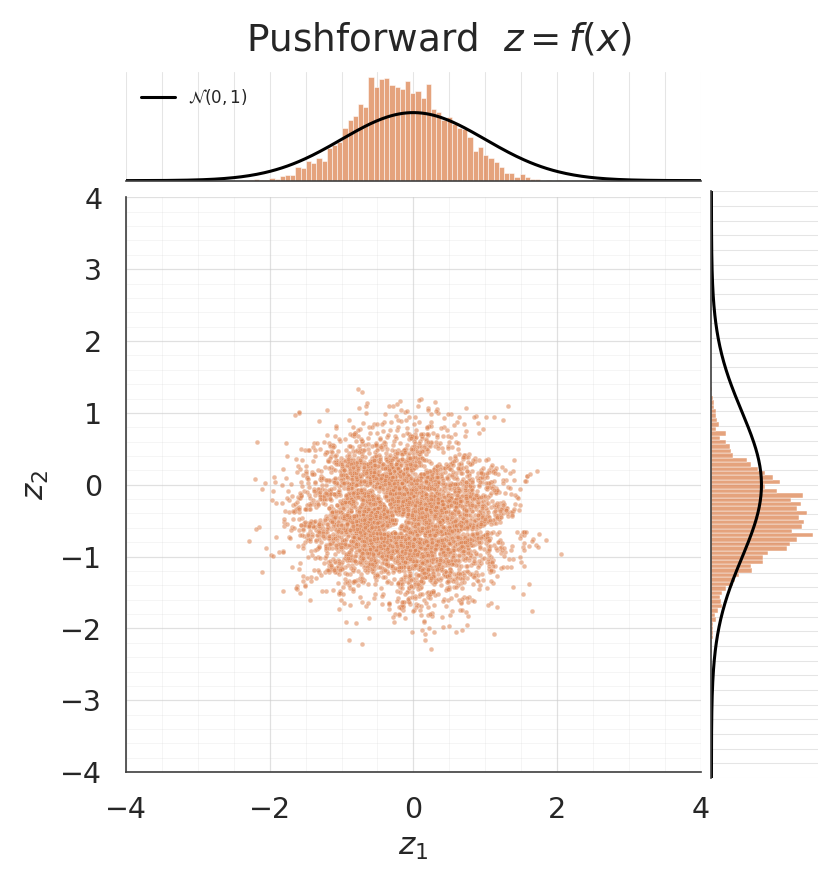

In [5]:
z = np.asarray(jax.vmap(trained.bijection.inverse)(X))

mean_z = z.mean(axis=0)
cov_z = np.cov(z, rowvar=False)
print("pushforward diagnostics")
print(f"  mean:      [{mean_z[0]:+.3f}, {mean_z[1]:+.3f}]   target = [0, 0]")
print(f"  cov[0,0]:  {cov_z[0, 0]:.3f}                  target = 1")
print(f"  cov[1,1]:  {cov_z[1, 1]:.3f}                  target = 1")
print(f"  cov[0,1]:  {cov_z[0, 1]:+.3f}                  target = 0")

g = sns.jointplot(
    x=z[:, 0],
    y=z[:, 1],
    kind="scatter",
    color=palette[1],
    height=7.5,
    ratio=5,
    space=0.1,
    joint_kws={"s": 10, "alpha": 0.55},
    marginal_kws={
        "bins": 60,
        "color": palette[1],
        "alpha": 0.75,
        "edgecolor": "white",
        "stat": "density",
    },
    xlim=(-4, 4),
    ylim=(-4, 4),
)
zz = np.linspace(-4, 4, 300)
phi = np.exp(-0.5 * zz**2) / np.sqrt(2 * np.pi)
g.ax_marg_x.plot(zz, phi, color="black", linewidth=2.0, label=r"$\mathcal{N}(0, 1)$")
g.ax_marg_y.plot(phi, zz, color="black", linewidth=2.0)
g.ax_marg_x.legend(loc="upper left", frameon=False, fontsize=11)
g.set_axis_labels("$z_1$", "$z_2$")
g.figure.suptitle(r"Pushforward  $z = f(x)$", y=1.02)
style_jointgrid(g)
plt.show()

## 5. Learned density $\log p_X(x)$

Evaluate the flow's exact density on a grid via `flow.log_prob`. For a normalising flow this is cheap: one forward pass plus the log-det accumulation — no Monte-Carlo integration is needed.

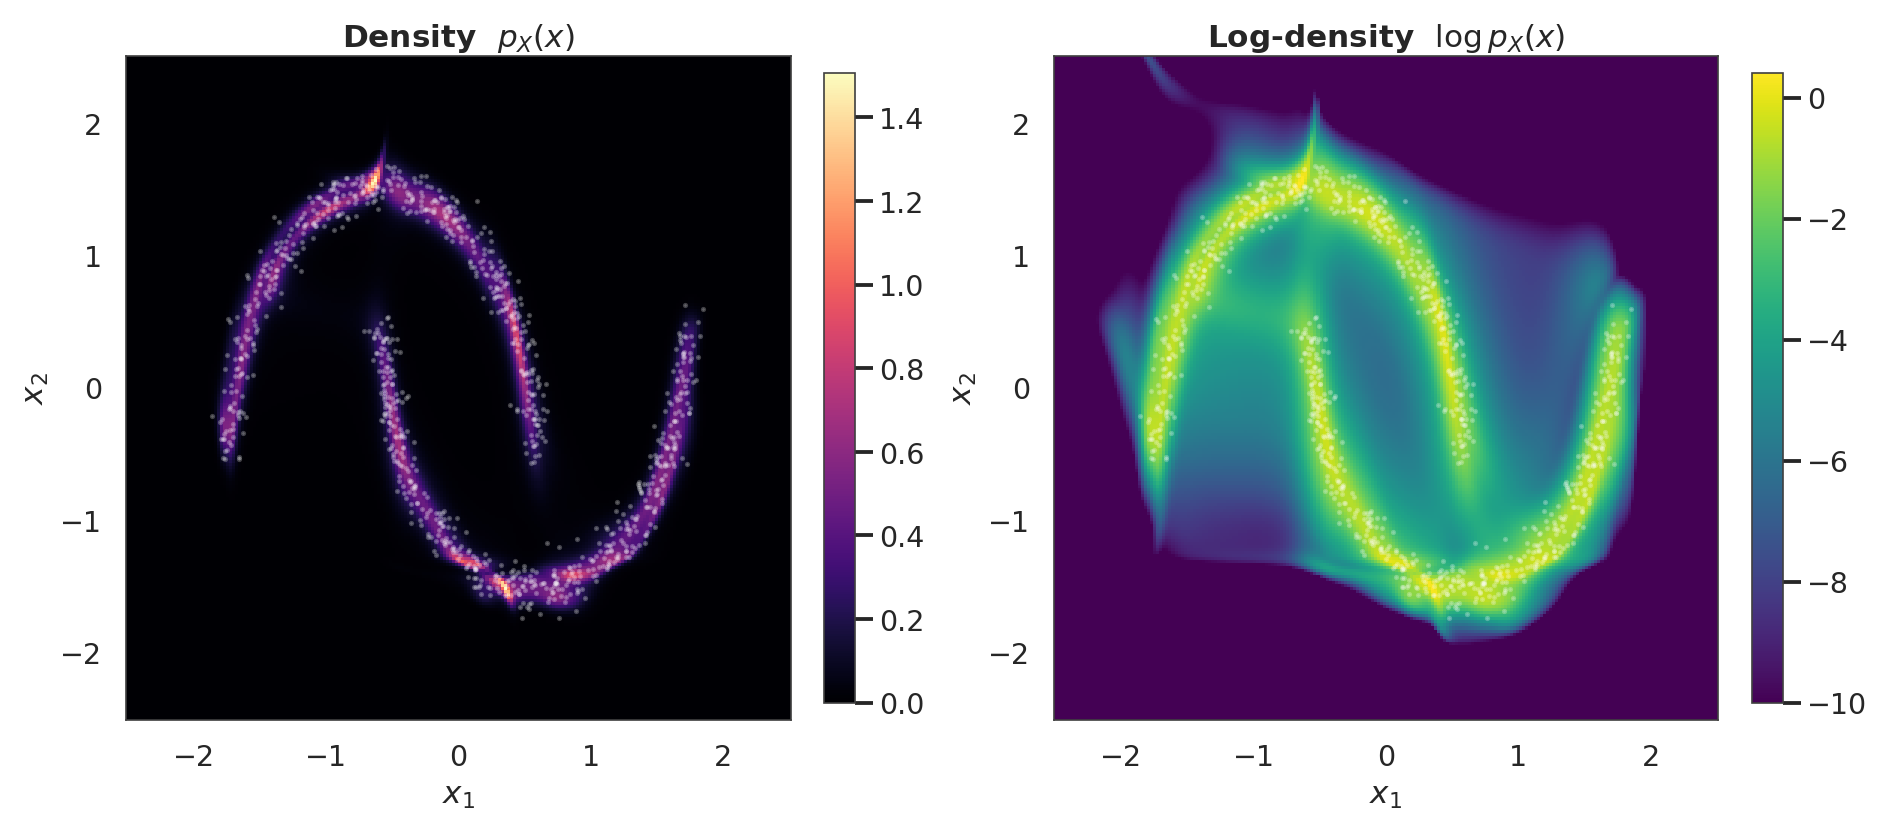

In [6]:
grid = 220
xs = np.linspace(-2.5, 2.5, grid).astype("float32")
ys = np.linspace(-2.5, 2.5, grid).astype("float32")
xx, yy = np.meshgrid(xs, ys)
pts = np.stack([xx.ravel(), yy.ravel()], axis=-1).astype("float32")

log_px = np.asarray(jax.vmap(trained.log_prob)(jnp.asarray(pts))).reshape(grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))

ax = axes[0]
pcm = ax.pcolormesh(xx, yy, np.exp(log_px), cmap="magma", shading="auto")
ax.scatter(
    np.asarray(X[:1000, 0]), np.asarray(X[:1000, 1]), s=2, alpha=0.25, color="white"
)
ax.set_title("Density  $p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)

ax = axes[1]
log_px_vis = np.clip(log_px, -10, None)
pcm = ax.pcolormesh(xx, yy, log_px_vis, cmap="viridis", shading="auto")
ax.scatter(
    np.asarray(X[:1000, 0]), np.asarray(X[:1000, 1]), s=2, alpha=0.25, color="white"
)
ax.set_title(r"Log-density  $\log p_X(x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
style_axes(ax, aspect="equal")
fig.colorbar(pcm, ax=ax, shrink=0.85)

plt.show()

## 6. Sampling from the flow

Draw $z \sim \mathcal{N}(0, I)$ and invert the composition: $x = f^{-1}(z)$. The inverse of each `MixtureGaussianCDF` layer uses a vectorised bisection on $F_i(x_i) = \Phi(z_i)$; the `HouseholderRotation` inverse is applying the reflections in reverse order (each reflection is self-inverse).

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


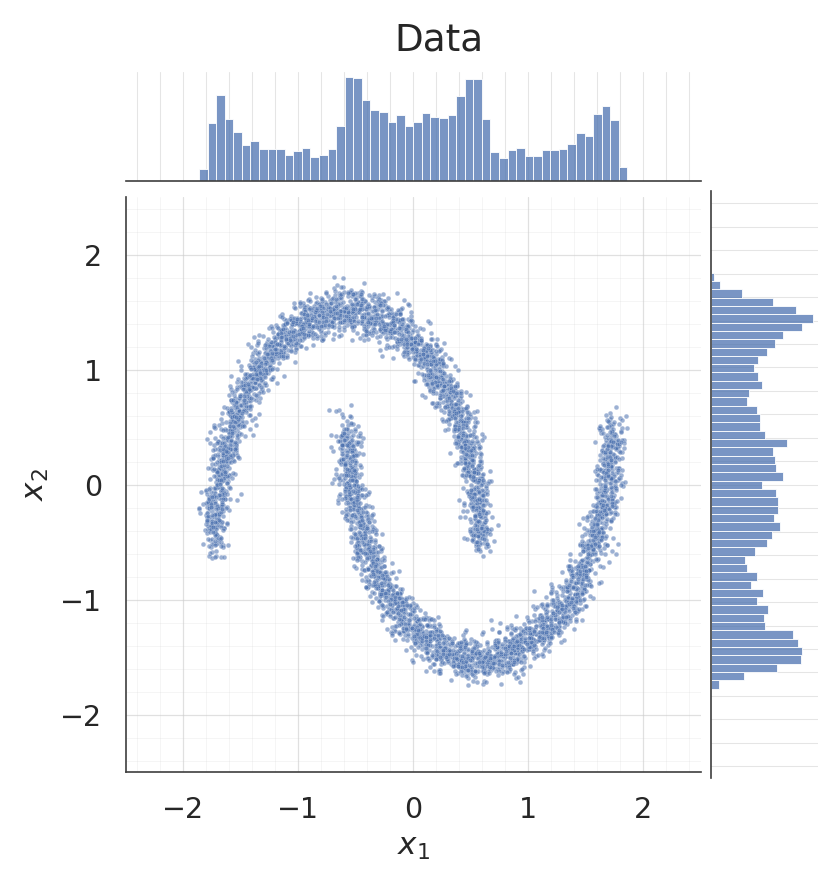

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


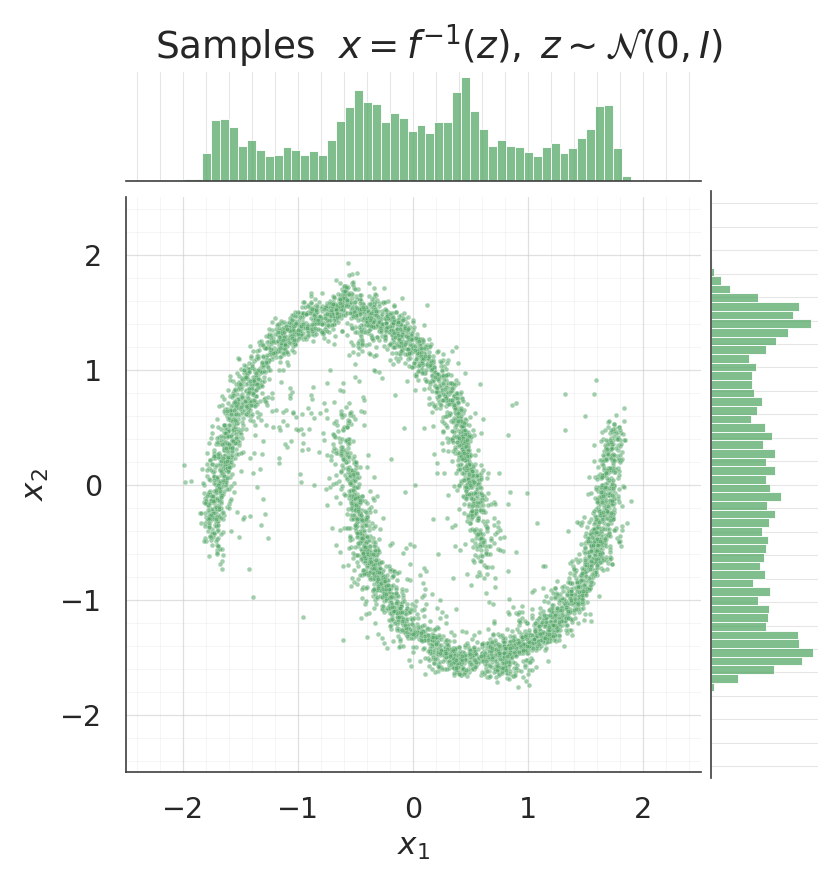

In [7]:
samples = np.asarray(trained.sample(sample_key, (5000,)))

for data, title, col in [
    (np.asarray(X), "Data", palette[0]),
    (samples, r"Samples  $x = f^{-1}(z), \; z \sim \mathcal{N}(0, I)$", palette[2]),
]:
    g = sns.jointplot(
        x=data[:, 0],
        y=data[:, 1],
        kind="scatter",
        color=col,
        height=7.5,
        ratio=5,
        space=0.1,
        joint_kws={"s": 10, "alpha": 0.55},
        marginal_kws={
            "bins": 50,
            "color": col,
            "alpha": 0.75,
            "edgecolor": "white",
        },
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
    )
    g.set_axis_labels("$x_1$", "$x_2$")
    g.figure.suptitle(title, y=1.02)
    style_jointgrid(g)
    plt.show()

## 7. Round-trip inversion

A flow is a bijection by construction, so $f^{-1}(f(x)) = x$ up to floating-point and the $\varepsilon$-clamp on $F(x) \in [\varepsilon, 1-\varepsilon]$ that keeps $\Phi^{-1}$ bounded. We verify this numerically on the training set.

round-trip L2 error  ||f^{-1}(f(x)) - x||_2
  median : 1.45e-06
  95th%  : 4.52e-05
  max    : 2.70e-04


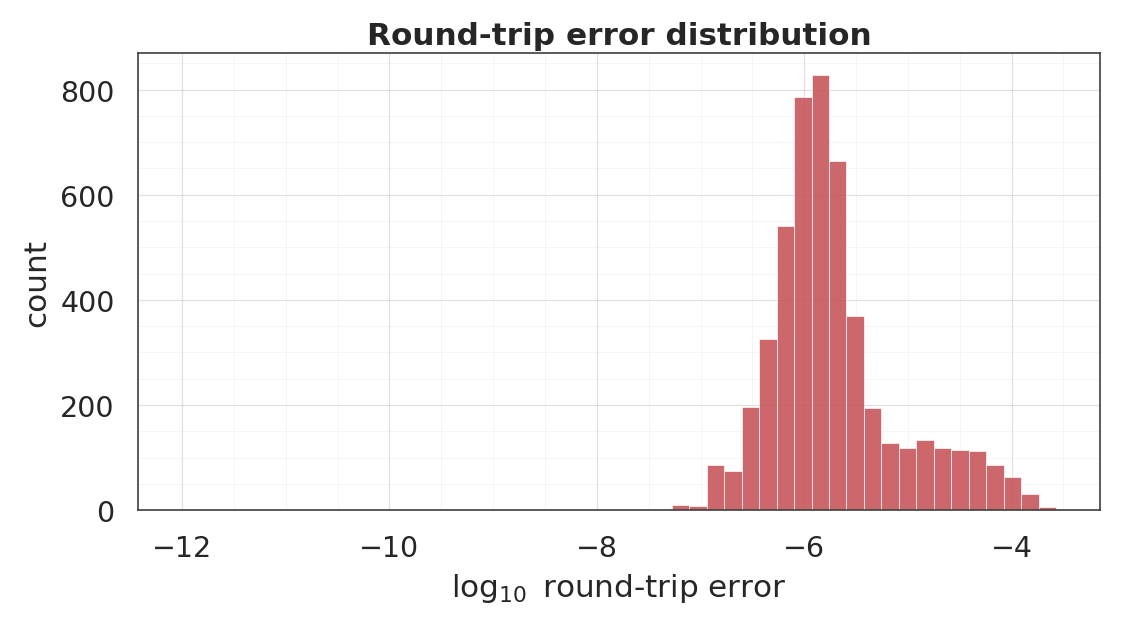

In [8]:
z_fwd = jax.vmap(trained.bijection.inverse)(X)
x_rt = jax.vmap(trained.bijection.transform)(z_fwd)
err = np.asarray(jnp.linalg.norm(x_rt - X, axis=-1))

print(r"round-trip L2 error  ||f^{-1}(f(x)) - x||_2")
print(f"  median : {np.median(err):.2e}")
print(f"  95th%  : {np.percentile(err, 95):.2e}")
print(f"  max    : {err.max():.2e}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(
    np.log10(err + 1e-12),
    bins=50,
    color=palette[3],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xlabel(r"$\log_{10}$ round-trip error")
ax.set_ylabel("count")
ax.set_title("Round-trip error distribution")
style_axes(ax)
plt.show()

## 8. Layer-by-layer Gaussianization

The intermediate states $x,\, f_1(x),\, (f_2 \circ f_1)(x), \ldots$ show how the distribution progressively deforms towards a standard normal. Rotations shuffle the mass across axes; marginal layers pull the per-dimension CDFs towards $\Phi$.

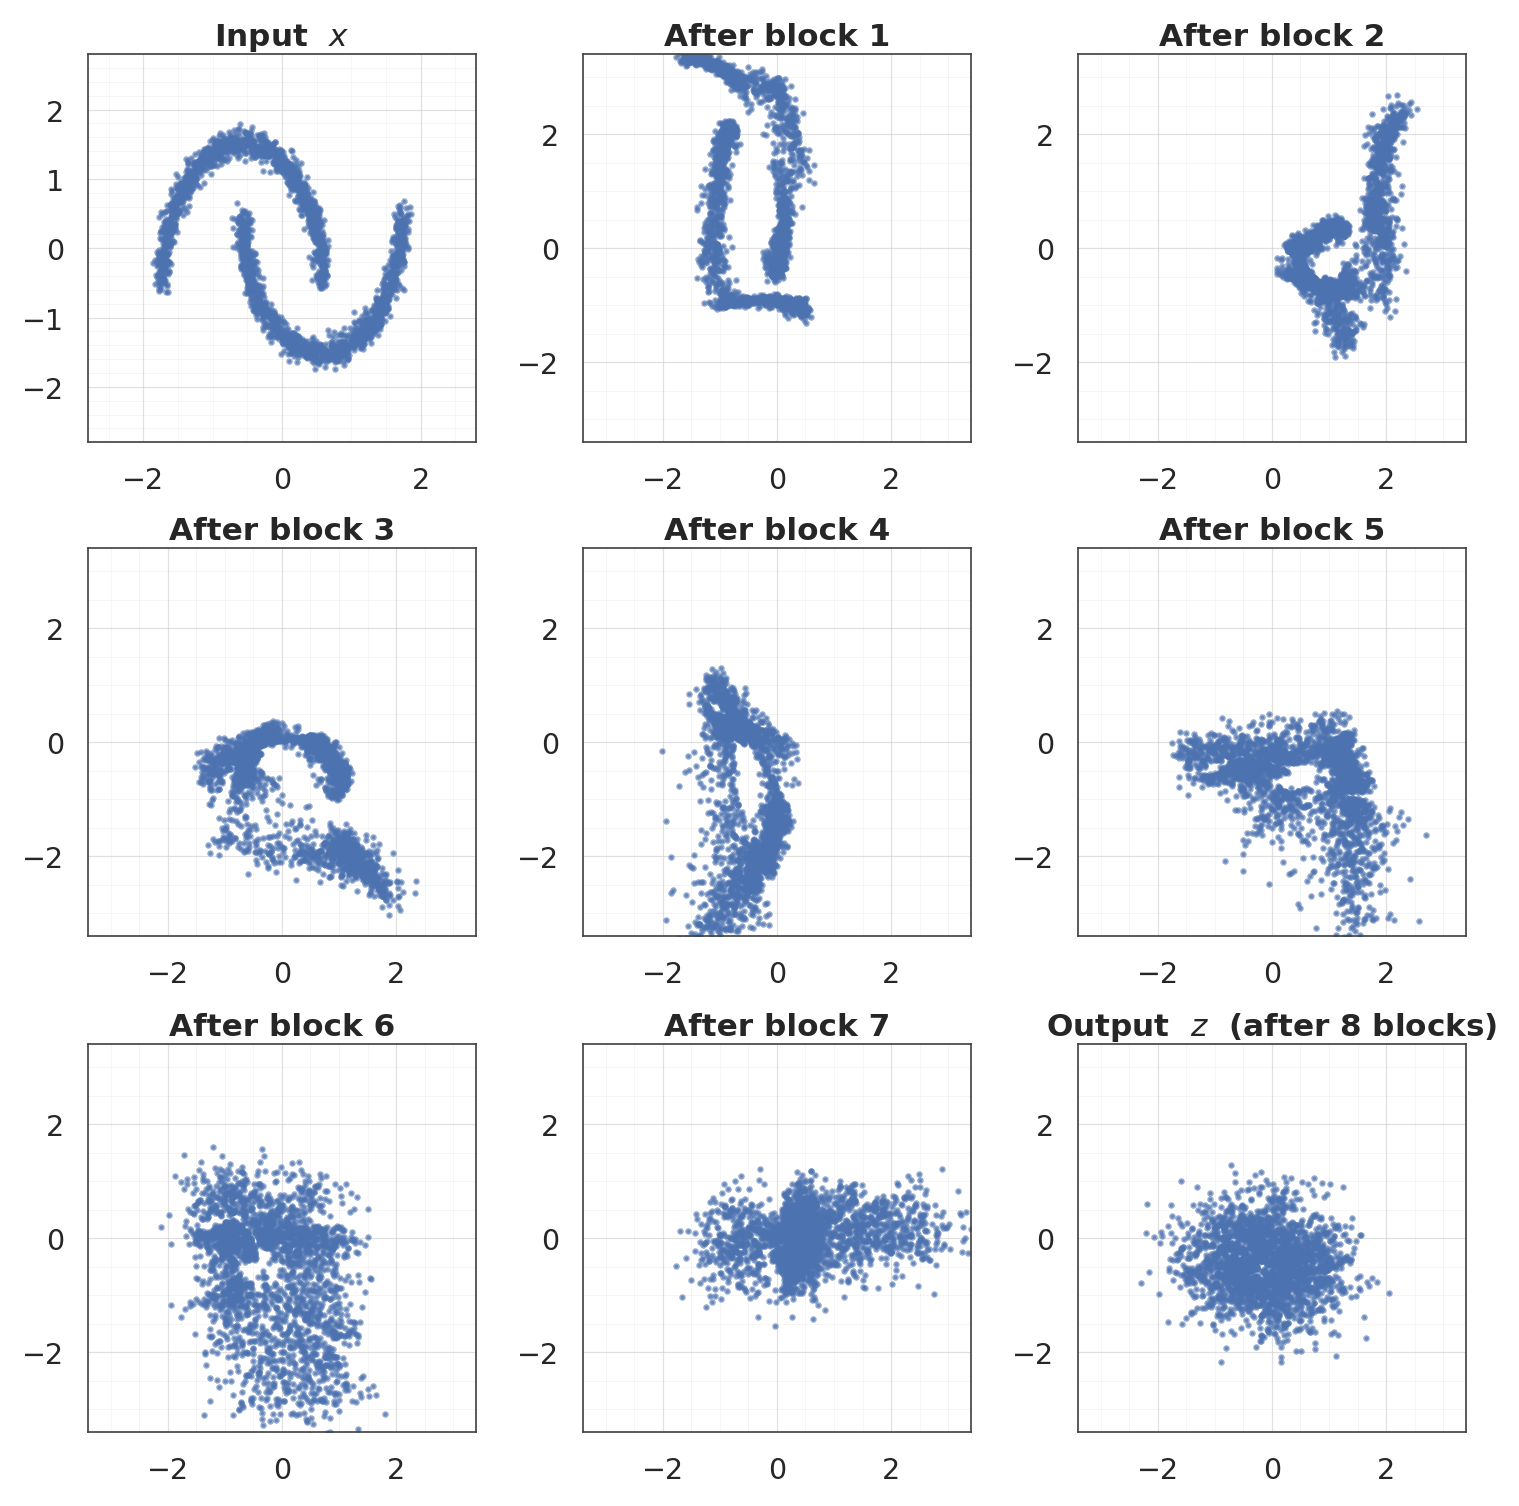

In [9]:
# Each "block" of `gaussianization_flow` is Chain([marginal, rotation]) with
# leaves vmapped across blocks. Slice block i out by indexing each leaf at i,
# then apply its transform. That gives us the intermediate state after block i.
scan_chain = trained.bijection.bijection.bijection  # Invert → Scan → Chain


def _slice_block(i, chain):
    return jax.tree_util.tree_map(
        lambda p: (
            p[i] if isinstance(p, jax.Array) and p.ndim > 0 and p.shape[0] == 8 else p
        ),
        chain,
    )


X_small = X[:2500]
states = [np.asarray(X_small)]
state = X_small
for i in range(8):
    block = _slice_block(i, scan_chain)
    state = jax.vmap(lambda s: block.transform_and_log_det(s)[0])(state)
    states.append(np.asarray(state))

n_states = len(states)
ncol = 3
nrow = int(np.ceil(n_states / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 4.5 * nrow))
axes = axes.ravel()
for i, (state, ax) in enumerate(zip(states, axes)):
    ax.scatter(state[:, 0], state[:, 1], s=5, alpha=0.6, color=palette[0])
    lim = 3.4 if i > 0 else 2.8
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    if i == 0:
        ax.set_title("Input  $x$")
    elif i == n_states - 1:
        ax.set_title(f"Output  $z$  (after {n_states - 1} blocks)")
    else:
        ax.set_title(f"After block {i}")
    style_axes(ax, aspect="equal")
for ax in axes[n_states:]:
    ax.axis("off")
plt.show()

## What to look at

- **Pushforward jointplot**: the scatter should look isotropic and the marginals should sit right under the black $\mathcal{N}(0, 1)$ curves.
- **Density contour**: should trace the two-moons shape. This is a learned bivariate density, evaluated in closed form on a grid.
- **Sample jointplots**: data and samples side-by-side — the 2-D morphology *and* the per-dim marginals should match.
- **Round-trip error**: numerical precision baseline for the bijection; typical error is $\lesssim 10^{-4}$ with a few tail outliers from the CDF clamp.
- **Layer-by-layer**: the intuition behind a Gaussianization flow — each `(Rotation, Marginal)` block nudges the distribution closer to $\mathcal{N}(0, I)$.